# Level / Gain Utilities

| Function | Description |
| --- | --- |
| `gain` | Apply gain in dB (positive = amplify, negative = attenuate). |
| `normalize` | Scale signal so its peak amplitude matches target_db. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.mixing import gain, normalize

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

`gain` and `normalize` operations on a 440 Hz reference sine (2 cycles).

**1 × 2 panels:**
- **Left — gain():** five gain values from −12 to +12 dB applied to the same sine; each 6 dB step doubles or halves amplitude; the waveform envelope visually spans a 4× amplitude range (−12 to +12 = 24 dB = 16× ratio in power)
- **Right — normalize():** three target peak levels (−12, −6, 0 dBFS); all waveforms share the same sinusoidal shape but the amplitude axis scale differs for each target

**Key distinction:**
- `gain(signal, gain_db)` applies a fixed dB offset regardless of the signal's current level — appropriate when the scaling factor is externally specified
- `normalize(signal, target_db)` always scales the peak to `target_db` dBFS — appropriate when the output level must hit a fixed ceiling independent of how loud the input is

Both are sample-accurate and require only one multiply per sample.


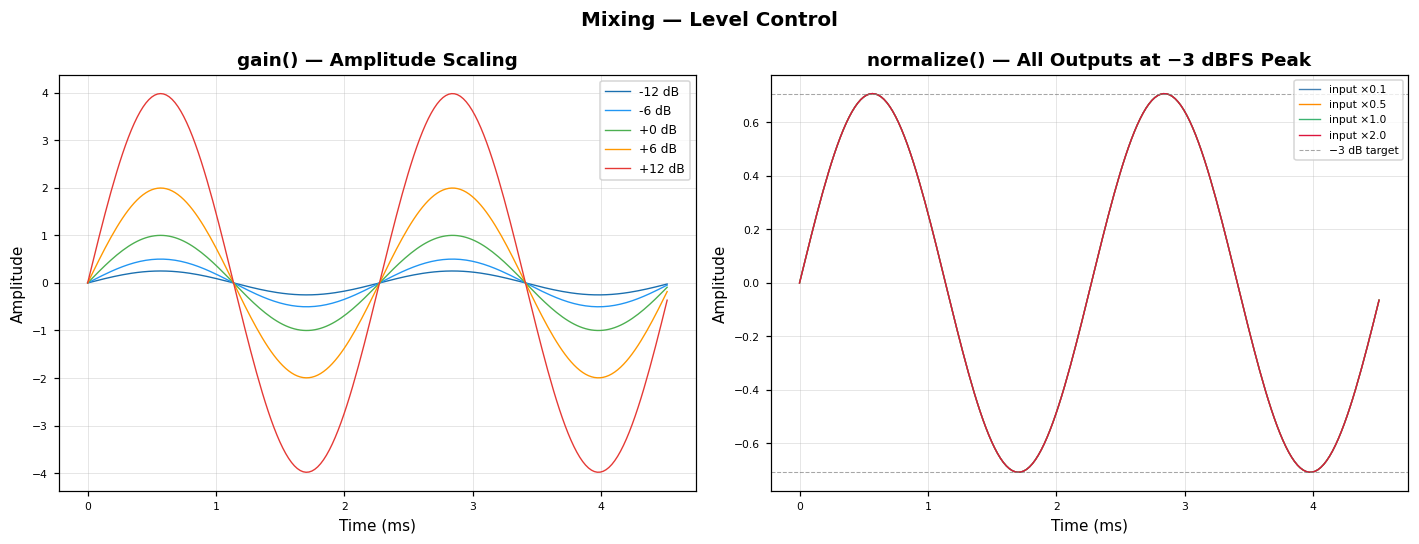

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 2 / FREQ

_, sig = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(sig)) / FS * 1000

GAINS_DB = [-12, -6, 0, 6, 12]
COLORS = ["#1a6faf", "#2196f3", "#4caf50", "#ff9800", "#e53935"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# gain
ax = axes[0]
for g_db, color in zip(GAINS_DB, COLORS):
    out = gain(sig, gain_db=g_db)
    ax.plot(t_ms, out, linewidth=0.9, color=color, label=f"{g_db:+d} dB")
ax.set_title("gain() — Amplitude Scaling", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, linewidth=0.4, alpha=0.5)

# normalize: show before/after for signals at different levels
levels = [0.1, 0.5, 1.0, 2.0]
norm_colors = ["steelblue", "darkorange", "mediumseagreen", "crimson"]
ax = axes[1]
for level, color in zip(levels, norm_colors):
    scaled = sig * level
    normed = normalize(scaled, target_db=-3.0)
    ax.plot(t_ms, normed, linewidth=0.9, color=color, label=f"input ×{level}")
ax.axhline(10 ** (-3 / 20), color="gray", linewidth=0.7, linestyle="--", alpha=0.7, label="−3 dB target")
ax.axhline(-10 ** (-3 / 20), color="gray", linewidth=0.7, linestyle="--", alpha=0.7)
ax.set_title("normalize() — All Outputs at −3 dBFS Peak", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

for ax in axes:
    ax.tick_params(labelsize=7)

fig.suptitle("Mixing — Level Control", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()